# FX Options Pricing

**Comprehensive guide to pricing FX options with BSM, Monte Carlo, and Finite Difference methods**

This notebook demonstrates FX option pricing across multiple product types:
- European Vanilla Options
- Barrier Options (knock-in, knock-out)
- Digital Options (cash-or-nothing)
- American Options (early exercise)

---

## Table of Contents

1. [Setup](#1-setup)
2. [European Vanilla Options](#2-european-vanilla-options)
3. [Barrier Options](#3-barrier-options)
4. [Digital Options](#4-digital-options)
5. [American Options](#5-american-options)
6. [Pricer Comparison](#6-pricer-comparison)
7. [Greeks Analysis](#7-greeks-analysis)

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from datetime import date

# QuantStrata imports - Market Data
from src.marketdata.core.ids import MarketId
from src.marketdata.core.market import Market
from src.marketdata.core.interfaces import Quote
from src.marketdata.surfaces.vol_surface import FlatVolSurface
from src.marketdata.curves.term_structure import FlatZeroRateCurve

# FX Instruments
from src.instruments.fx.options.vanilla import EuropeanFxVanillaOption, AmericanFxVanillaOption
from src.instruments.fx.options.barrier import EuropeanFxBarrierOption
from src.instruments.fx.options.digital import EuropeanFxDigitalOption

# FX Pricers
from src.pricers.fx.european_bsm import FxEuropeanVanillaBsmPricer, FxEuropeanDigitalBsmPricer
from src.pricers.fx.european_bsm_mc import FxEuropeanVanillaMcPricer, FxEuropeanBarrierMcPricer
from src.pricers.fx.european_bsm_fde import FxEuropeanVanillaFdPricer
from src.pricers.fx.american_bsm_fde import FxAmericanVanillaFdPricer

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
})

print("Imports successful!")

Imports successful!


---

## 1. Setup

### Define Market Identifiers

In [2]:
# Define standard MarketIds for EURUSD
SPOT_ID = MarketId("FX", "SPOT", "EURUSD", (("dom", "USD"), ("for", "EUR")))
VOL_ID = MarketId("FX", "VOL", "EURUSD", (("dom", "USD"), ("for", "EUR")))
USD_CURVE_ID = MarketId("IR", "CURVE", "USD.OIS", (("ccy", "USD"),))
EUR_CURVE_ID = MarketId("IR", "CURVE", "EUR.OIS", (("ccy", "EUR"),))

print("MarketIds defined:")
print(f"  Spot:      {SPOT_ID.key()}")
print(f"  Vol:       {VOL_ID.key()}")
print(f"  USD Curve: {USD_CURVE_ID.key()}")
print(f"  EUR Curve: {EUR_CURVE_ID.key()}")

MarketIds defined:
  Spot:      FX.SPOT.EURUSD|dom=USD|for=EUR
  Vol:       FX.VOL.EURUSD|dom=USD|for=EUR
  USD Curve: IR.CURVE.USD.OIS|ccy=USD
  EUR Curve: IR.CURVE.EUR.OIS|ccy=EUR


In [3]:
def create_fx_market(
    spot: float = 1.10,
    vol: float = 0.08,
    r_dom: float = 0.05,
    r_for: float = 0.03,
) -> Market:
    """
    Create an FX market snapshot for EURUSD.
    
    Parameters
    ----------
    spot : float
        EURUSD spot rate (USD per EUR).
    vol : float
        Implied volatility.
    r_dom : float
        USD (domestic) risk-free rate.
    r_for : float
        EUR (foreign) risk-free rate.
    
    Returns
    -------
    Market
        Configured FX market snapshot.
    """
    return Market(
        asof="2026-01-15",
        quotes={
            SPOT_ID: Quote(value=spot),
        },
        curves={
            USD_CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=r_dom),
            EUR_CURVE_ID: FlatZeroRateCurve(continuously_compounded_rate=r_for),
        },
        vols={
            VOL_ID: FlatVolSurface(sigma=vol),
        },
    )

# Create base market
market = create_fx_market(spot=1.10, vol=0.08, r_dom=0.05, r_for=0.03)

print("Base Market:")
print(f"  EURUSD Spot: {market.quote(SPOT_ID):.4f}")
print(f"  Vol:         {market.vol_surface(VOL_ID).vol(1.0, 1.10):.0%}")
print(f"  USD Rate:    {market.curve(USD_CURVE_ID).zero_rate(1.0):.1%}")
print(f"  EUR Rate:    {market.curve(EUR_CURVE_ID).zero_rate(1.0):.1%}")

# Compute forward rate
import math
forward_1y = 1.10 * math.exp((0.05 - 0.03) * 1.0)
print(f"  Forward (1Y): {forward_1y:.4f}")

Base Market:
  EURUSD Spot: 1.1000
  Vol:         8%
  USD Rate:    5.0%
  EUR Rate:    3.0%
  Forward (1Y): 1.1222


---

## 2. European Vanilla Options

### 2.1 Basic Pricing

In [4]:
# Create ATM call and put options
call_option = EuropeanFxVanillaOption(
    option_type="call",
    notional=1_000_000,  # EUR 1M
    strike=1.10,         # ATM
    expiry=1.0,          # 1 year
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

put_option = EuropeanFxVanillaOption(
    option_type="put",
    notional=1_000_000,
    strike=1.10,
    expiry=1.0,
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

# Price with BSM
bsm_pricer = FxEuropeanVanillaBsmPricer()

call_pv = bsm_pricer.price(call_option, market)
put_pv = bsm_pricer.price(put_option, market)

print("ATM European Vanilla Options (K=1.10, T=1Y):")
print(f"  Call PV: ${call_pv:,.2f}")
print(f"  Put PV:  ${put_pv:,.2f}")

# Verify put-call parity: C - P = S*e^(-r_f*T) - K*e^(-r_d*T)
S, K, T, r_d, r_f = 1.10, 1.10, 1.0, 0.05, 0.03
parity_rhs = S * math.exp(-r_f * T) - K * math.exp(-r_d * T)
parity_lhs = (call_pv - put_pv) / 1_000_000  # Per unit notional

print(f"\nPut-Call Parity Check:")
print(f"  C - P = {parity_lhs:.6f}")
print(f"  S*e^(-r_f*T) - K*e^(-r_d*T) = {parity_rhs:.6f}")
print(f"  Match: {np.isclose(parity_lhs, parity_rhs, rtol=1e-6)}")

ATM European Vanilla Options (K=1.10, T=1Y):
  Call PV: $45,339.70
  Put PV:  $24,201.98

Put-Call Parity Check:
  C - P = 0.021138
  S*e^(-r_f*T) - K*e^(-r_d*T) = 0.021138
  Match: True


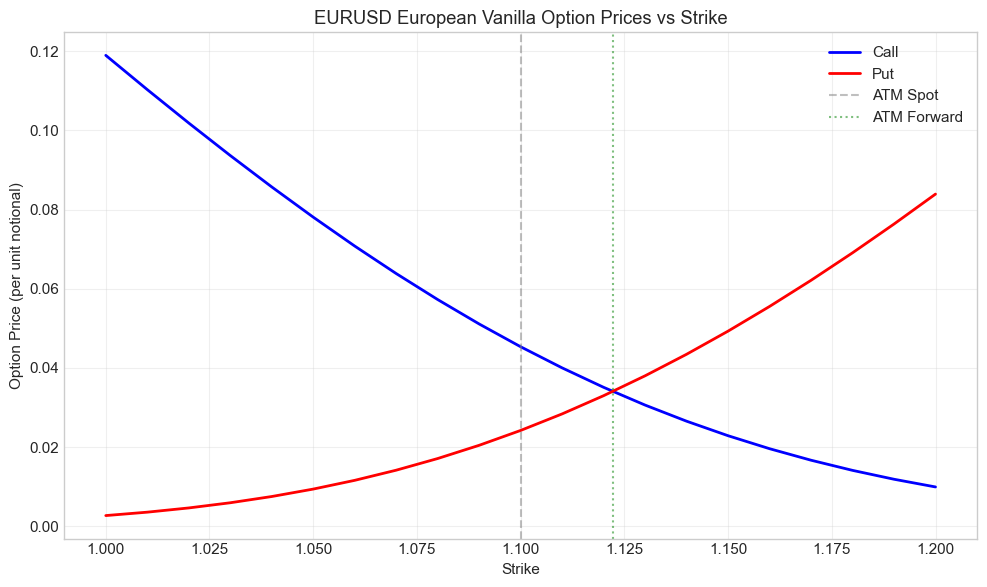

In [5]:
# Price across strikes
strikes = np.linspace(1.00, 1.20, 21)

call_prices = []
put_prices = []

for K in strikes:
    call = EuropeanFxVanillaOption(
        option_type="call", notional=1.0, strike=K, expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    put = EuropeanFxVanillaOption(
        option_type="put", notional=1.0, strike=K, expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    call_prices.append(bsm_pricer.price(call, market))
    put_prices.append(bsm_pricer.price(put, market))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strikes, call_prices, 'b-', label='Call', linewidth=2)
ax.plot(strikes, put_prices, 'r-', label='Put', linewidth=2)
ax.axvline(1.10, color='gray', linestyle='--', alpha=0.5, label='ATM Spot')
ax.axvline(forward_1y, color='green', linestyle=':', alpha=0.5, label='ATM Forward')

ax.set_xlabel('Strike')
ax.set_ylabel('Option Price (per unit notional)')
ax.set_title('EURUSD European Vanilla Option Prices vs Strike')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. Barrier Options

### 3.1 Knock-Out Options

In [6]:
# Down-and-Out Call: Knocked out if spot falls below barrier
down_out_call = EuropeanFxBarrierOption(
    option_type="call",
    notional=1_000_000,
    strike=1.10,
    expiry=1.0,
    barrier_level=1.05,        # Barrier level
    barrier_direction="down",
    barrier_style="knock_out",
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

# Up-and-Out Put: Knocked out if spot rises above barrier
up_out_put = EuropeanFxBarrierOption(
    option_type="put",
    notional=1_000_000,
    strike=1.10,
    expiry=1.0,
    barrier_level=1.15,
    barrier_direction="up",
    barrier_style="knock_out",
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

# Price with Monte Carlo
mc_barrier_pricer = FxEuropeanBarrierMcPricer(n_paths=100000, seed=42)

do_call_result = mc_barrier_pricer.price(down_out_call, market)
uo_put_result = mc_barrier_pricer.price(up_out_put, market)

# Get prices from simulation results
do_call_pv = do_call_result.price if hasattr(do_call_result, 'price') else do_call_result
uo_put_pv = uo_put_result.price if hasattr(uo_put_result, 'price') else uo_put_result

print("Knock-Out Barrier Options:")
print(f"  Down-and-Out Call (K=1.10, B=1.05): ${do_call_pv:,.2f}")
print(f"  Up-and-Out Put (K=1.10, B=1.15):   ${uo_put_pv:,.2f}")

# Compare to vanilla
print(f"\nComparison to Vanilla:")
print(f"  Vanilla Call: ${call_pv:,.2f}")
print(f"  D&O Call:     ${do_call_pv:,.2f} ({do_call_pv/call_pv:.1%} of vanilla)")

Knock-Out Barrier Options:
  Down-and-Out Call (K=1.10, B=1.05): $40,630.57
  Up-and-Out Put (K=1.10, B=1.15):   $20,734.82

Comparison to Vanilla:
  Vanilla Call: $45,339.70
  D&O Call:     $40,630.57 (89.6% of vanilla)


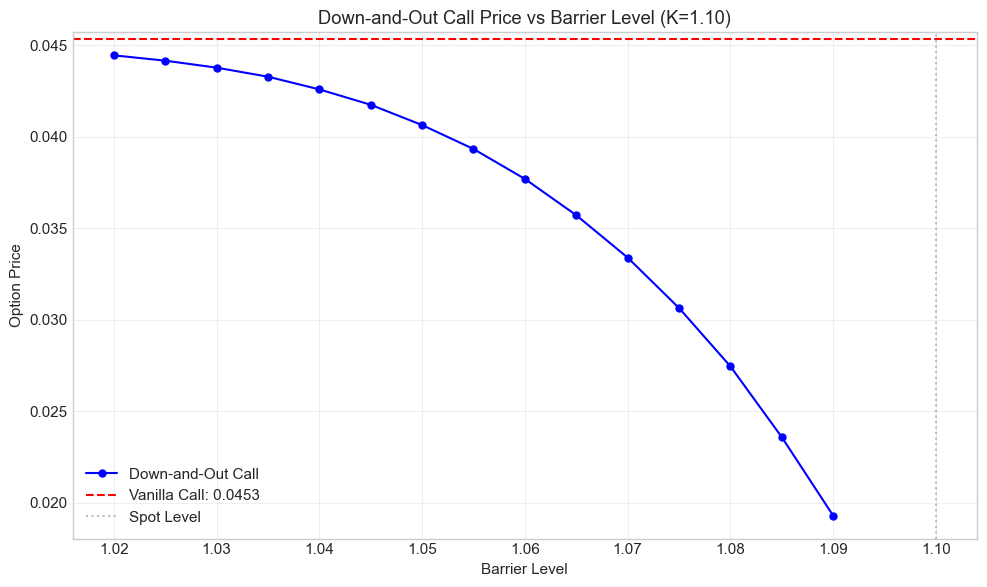

Intuition: Lower barrier = higher probability of survival = higher price


In [7]:
# Price barrier options across barrier levels
barriers = np.linspace(1.02, 1.09, 15)
do_call_prices = []

for B in barriers:
    opt = EuropeanFxBarrierOption(
        option_type="call", notional=1.0, strike=1.10, expiry=1.0,
        barrier_level=B, barrier_direction="down", barrier_style="knock_out",
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    result = mc_barrier_pricer.price(opt, market)
    price = result.price if hasattr(result, 'price') else result
    do_call_prices.append(price)

# Vanilla price for reference
vanilla_call = EuropeanFxVanillaOption(
    option_type="call", notional=1.0, strike=1.10, expiry=1.0,
    spot_id=SPOT_ID, vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
)
vanilla_price = bsm_pricer.price(vanilla_call, market)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(barriers, do_call_prices, 'b-o', label='Down-and-Out Call', markersize=5)
ax.axhline(vanilla_price, color='red', linestyle='--', label=f'Vanilla Call: {vanilla_price:.4f}')
ax.axvline(1.10, color='gray', linestyle=':', alpha=0.5, label='Spot Level')

ax.set_xlabel('Barrier Level')
ax.set_ylabel('Option Price')
ax.set_title('Down-and-Out Call Price vs Barrier Level (K=1.10)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Intuition: Lower barrier = higher probability of survival = higher price")

---

## 4. Digital Options

### 4.1 Cash-or-Nothing Options

In [8]:
# Cash-or-nothing digital call: pays fixed amount if S_T > K
digital_call = EuropeanFxDigitalOption(
    option_type="call",
    payout_amount=1_000_000,  # USD payout if ITM
    strike=1.10,
    expiry=1.0,
    payoff="cash",
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

digital_put = EuropeanFxDigitalOption(
    option_type="put",
    payout_amount=1_000_000,
    strike=1.10,
    expiry=1.0,
    payoff="cash",
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

# Price with BSM
digital_pricer = FxEuropeanDigitalBsmPricer()

digital_call_pv = digital_pricer.price(digital_call, market)
digital_put_pv = digital_pricer.price(digital_put, market)

print("Cash-or-Nothing Digital Options (K=1.10, T=1Y):")
print(f"  Digital Call PV: ${digital_call_pv:,.2f}")
print(f"  Digital Put PV:  ${digital_put_pv:,.2f}")

# Digital call + put = discounted notional
df_dom = math.exp(-0.05 * 1.0)
print(f"\nDigital Put-Call Parity:")
print(f"  Call + Put = ${digital_call_pv + digital_put_pv:,.2f}")
print(f"  DF × Notional = ${df_dom * 1_000_000:,.2f}")

Cash-or-Nothing Digital Options (K=1.10, T=1Y):
  Digital Call PV: $554,724.81
  Digital Put PV:  $396,504.61

Digital Put-Call Parity:
  Call + Put = $951,229.42
  DF × Notional = $951,229.42


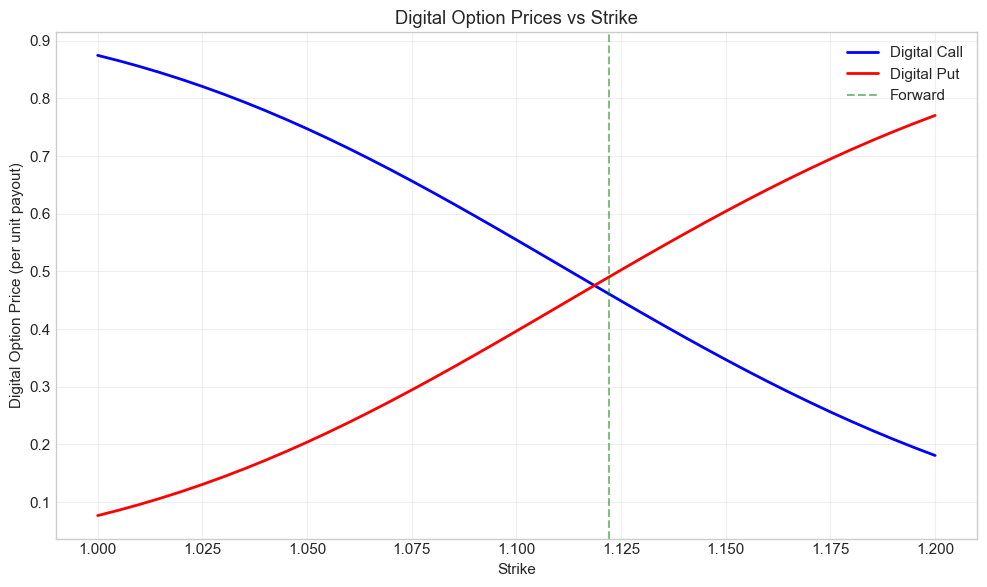

Note: Digital prices represent probability of ITM (times discount factor)


In [9]:
# Digital option prices across strikes
strikes = np.linspace(1.00, 1.20, 41)
digital_call_prices = []
digital_put_prices = []

for K in strikes:
    call = EuropeanFxDigitalOption(
        option_type="call", payout_amount=1.0, strike=K, expiry=1.0, payoff="cash",
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    put = EuropeanFxDigitalOption(
        option_type="put", payout_amount=1.0, strike=K, expiry=1.0, payoff="cash",
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    digital_call_prices.append(digital_pricer.price(call, market))
    digital_put_prices.append(digital_pricer.price(put, market))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strikes, digital_call_prices, 'b-', label='Digital Call', linewidth=2)
ax.plot(strikes, digital_put_prices, 'r-', label='Digital Put', linewidth=2)
ax.axvline(forward_1y, color='green', linestyle='--', alpha=0.5, label='Forward')

ax.set_xlabel('Strike')
ax.set_ylabel('Digital Option Price (per unit payout)')
ax.set_title('Digital Option Prices vs Strike')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: Digital prices represent probability of ITM (times discount factor)")

---

## 5. American Options

### 5.1 Early Exercise Premium

In [10]:
# American options
american_call = AmericanFxVanillaOption(
    option_type="call",
    notional=1_000_000,
    strike=1.10,
    expiry=1.0,
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

american_put = AmericanFxVanillaOption(
    option_type="put",
    notional=1_000_000,
    strike=1.10,
    expiry=1.0,
    spot_id=SPOT_ID,
    vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID,
    foreign_curve_id=EUR_CURVE_ID,
)

# Price with Finite Difference
fd_american_pricer = FxAmericanVanillaFdPricer()

amer_call_pv = fd_american_pricer.price(american_call, market)
amer_put_pv = fd_american_pricer.price(american_put, market)

print("American vs European Options (K=1.10, T=1Y):")
print(f"\n{'Option':<15} {'European':>12} {'American':>12} {'Early Ex Premium':>18}")
print("-" * 60)
print(f"{'Call':<15} ${call_pv:>10,.2f} ${amer_call_pv:>10,.2f} ${amer_call_pv - call_pv:>16,.2f}")
print(f"{'Put':<15} ${put_pv:>10,.2f} ${amer_put_pv:>10,.2f} ${amer_put_pv - put_pv:>16,.2f}")

American vs European Options (K=1.10, T=1Y):

Option              European     American   Early Ex Premium
------------------------------------------------------------
Call            $ 45,339.70 $ 45,331.88 $           -7.82
Put             $ 24,201.98 $ 26,605.17 $        2,403.19


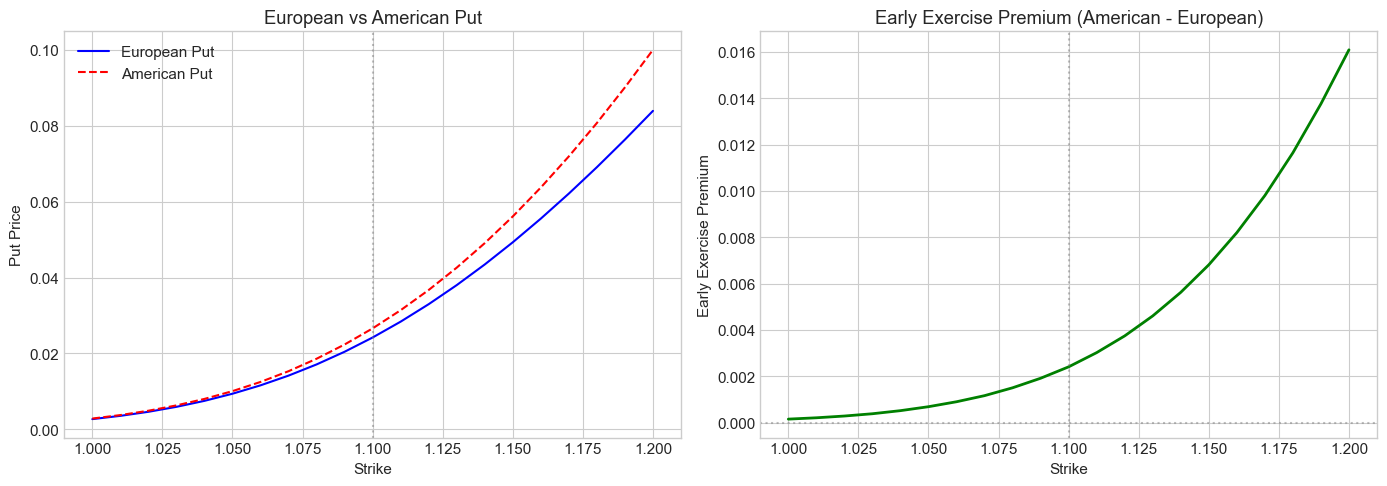

Max early exercise premium: 0.016090 at K=1.20


In [11]:
# Compare European vs American puts across strikes
strikes = np.linspace(1.00, 1.20, 21)
eur_puts = []
amer_puts = []

for K in strikes:
    eur = EuropeanFxVanillaOption(
        option_type="put", notional=1.0, strike=K, expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    amer = AmericanFxVanillaOption(
        option_type="put", notional=1.0, strike=K, expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    eur_puts.append(bsm_pricer.price(eur, market))
    amer_puts.append(fd_american_pricer.price(amer, market))

early_ex_premium = np.array(amer_puts) - np.array(eur_puts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(strikes, eur_puts, 'b-', label='European Put')
ax.plot(strikes, amer_puts, 'r--', label='American Put')
ax.axvline(1.10, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Put Price')
ax.set_title('European vs American Put')
ax.legend()

ax = axes[1]
ax.plot(strikes, early_ex_premium, 'g-', linewidth=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(1.10, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Early Exercise Premium')
ax.set_title('Early Exercise Premium (American - European)')

plt.tight_layout()
plt.show()

print(f"Max early exercise premium: {max(early_ex_premium):.6f} at K={strikes[np.argmax(early_ex_premium)]:.2f}")

---

## 6. Pricer Comparison

### 6.1 BSM vs Monte Carlo vs Finite Difference

In [12]:
# Create pricers
bsm_pricer = FxEuropeanVanillaBsmPricer()
mc_pricer = FxEuropeanVanillaMcPricer(n_paths=100000, seed=42)
fd_pricer = FxEuropeanVanillaFdPricer()

# Test option
test_call = EuropeanFxVanillaOption(
    option_type="call", notional=1_000_000, strike=1.10, expiry=1.0,
    spot_id=SPOT_ID, vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
)

# Price with all three methods
bsm_price = bsm_pricer.price(test_call, market)
mc_result = mc_pricer.price(test_call, market)
mc_price = mc_result.price if hasattr(mc_result, 'price') else mc_result
fd_price = fd_pricer.price(test_call, market)

print("Pricer Comparison - ATM Call (K=1.10, T=1Y):")
print(f"\n{'Method':<20} {'Price':>15} {'vs BSM':>12}")
print("-" * 50)
print(f"{'BSM (Analytic)':<20} ${bsm_price:>13,.2f} {'(reference)':>12}")
print(f"{'Monte Carlo (100k)':<20} ${mc_price:>13,.2f} {(mc_price/bsm_price - 1)*100:>11.3f}%")
print(f"{'Finite Difference':<20} ${fd_price:>13,.2f} {(fd_price/bsm_price - 1)*100:>11.3f}%")

Pricer Comparison - ATM Call (K=1.10, T=1Y):

Method                         Price       vs BSM
--------------------------------------------------
BSM (Analytic)       $    45,339.70  (reference)
Monte Carlo (100k)   $    45,397.63       0.128%
Finite Difference    $    45,331.89      -0.017%


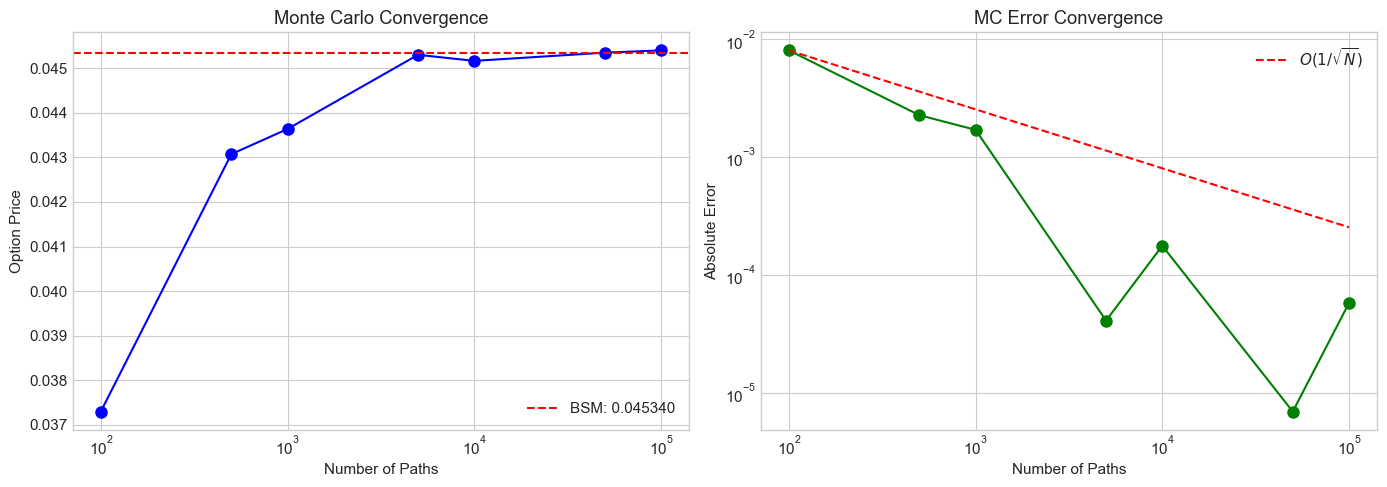

In [13]:
# Monte Carlo convergence
path_counts = [100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = []
mc_errors = []

test_call_unit = EuropeanFxVanillaOption(
    option_type="call", notional=1.0, strike=1.10, expiry=1.0,
    spot_id=SPOT_ID, vol_id=VOL_ID,
    domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
)
bsm_ref = bsm_pricer.price(test_call_unit, market)

for n in path_counts:
    mc = FxEuropeanVanillaMcPricer(n_paths=n, seed=42)
    result = mc.price(test_call_unit, market)
    price = result.price if hasattr(result, 'price') else result
    mc_prices.append(price)
    mc_errors.append(abs(price - bsm_ref))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(path_counts, mc_prices, 'bo-', markersize=8)
ax.axhline(bsm_ref, color='red', linestyle='--', label=f'BSM: {bsm_ref:.6f}')
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Option Price')
ax.set_title('Monte Carlo Convergence')
ax.legend()

ax = axes[1]
ax.loglog(path_counts, mc_errors, 'go-', markersize=8)
x = np.array(path_counts)
if mc_errors[0] > 0:
    ax.loglog(x, mc_errors[0] * np.sqrt(path_counts[0]) / np.sqrt(x), 'r--', label=r'$O(1/\sqrt{N})$')
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Absolute Error')
ax.set_title('MC Error Convergence')
ax.legend()

plt.tight_layout()
plt.show()

---

## 7. Greeks Analysis

### 7.1 Delta and Gamma

In [14]:
# Get Greeks from BSM pricer
call_greeks = bsm_pricer.greeks(call_option, market)
put_greeks = bsm_pricer.greeks(put_option, market)

print("Greeks for ATM Options (K=1.10, T=1Y, Notional=1M EUR):")
print(f"\n{'Greek':<15} {'Call':>15} {'Put':>15}")
print("-" * 45)

for greek in ['delta', 'gamma', 'vega', 'theta']:
    if greek in call_greeks:
        call_val = call_greeks[greek]
        put_val = put_greeks[greek]
        print(f"{greek.capitalize():<15} {call_val:>15,.2f} {put_val:>15,.2f}")

Greeks for ATM Options (K=1.10, T=1Y, Notional=1M EUR):

Greek                      Call             Put
---------------------------------------------
Delta                595,942.72     -374,502.81
Gamma              4,218,290.42    4,218,290.42
Vega                 408,330.51      408,330.51
Theta                -27,176.98       -6,884.06


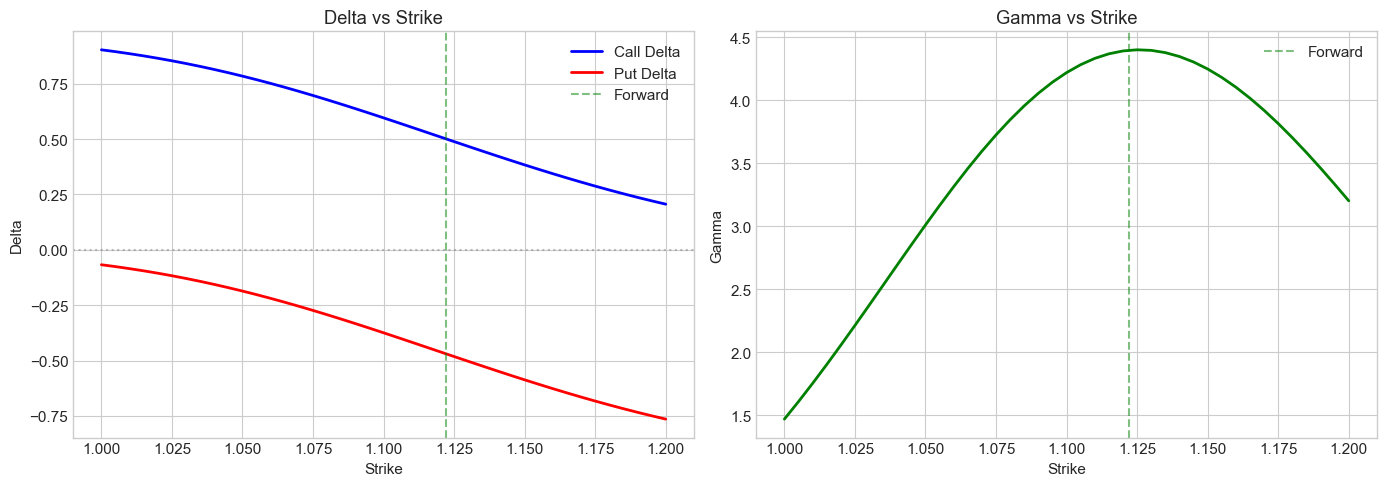

Maximum Gamma at K=1.1250 (close to forward 1.1222)


In [15]:
# Delta across strikes
strikes = np.linspace(1.00, 1.20, 41)
call_deltas = []
put_deltas = []
gammas = []

for K in strikes:
    call = EuropeanFxVanillaOption(
        option_type="call", notional=1.0, strike=K, expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    put = EuropeanFxVanillaOption(
        option_type="put", notional=1.0, strike=K, expiry=1.0,
        spot_id=SPOT_ID, vol_id=VOL_ID,
        domestic_curve_id=USD_CURVE_ID, foreign_curve_id=EUR_CURVE_ID,
    )
    call_g = bsm_pricer.greeks(call, market)
    put_g = bsm_pricer.greeks(put, market)
    call_deltas.append(call_g['delta'])
    put_deltas.append(put_g['delta'])
    gammas.append(call_g['gamma'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(strikes, call_deltas, 'b-', label='Call Delta', linewidth=2)
ax.plot(strikes, put_deltas, 'r-', label='Put Delta', linewidth=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(forward_1y, color='green', linestyle='--', alpha=0.5, label='Forward')
ax.set_xlabel('Strike')
ax.set_ylabel('Delta')
ax.set_title('Delta vs Strike')
ax.legend()

ax = axes[1]
ax.plot(strikes, gammas, 'g-', linewidth=2)
ax.axvline(forward_1y, color='green', linestyle='--', alpha=0.5, label='Forward')
ax.set_xlabel('Strike')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Strike')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Maximum Gamma at K={strikes[np.argmax(gammas)]:.4f} (close to forward {forward_1y:.4f})")

---

## Summary

**Products Covered:**

| Product | Pricer | Key Features |
|---------|--------|-------------|
| European Vanilla | BSM, MC, FDE | Closed-form Greeks |
| Barrier Options | MC | Path-dependent |
| Digital Options | BSM | Binary payoff |
| American Options | FDE | Early exercise via PSOR |

**Key Takeaways:**

1. **BSM** is exact for European vanillas - use for benchmarking
2. **Monte Carlo** is flexible for path-dependent products (barriers, Asians)
3. **Finite Difference** handles early exercise (American options)
4. **Barrier options** are cheaper than vanilla (knockout risk)
5. **Digital options** prices ≈ risk-neutral probability × discount factor
6. **American premium** is most significant for ITM puts